# Assignment 12: Predicting Hotel Booking Cancellations  
## Models: Naïve Bayes, Support Vector Machine (SVM), and Neural Network

**Objectives:**
- Understand how to use classification models (Naïve Bayes, SVM, Neural Networks) to predict hotel cancellations.
- Compare models in terms of accuracy, complexity, and business relevance.
- Interpret and communicate model results from a business perspective.

## Business Scenario

You work as a data analyst for a hospitality group that manages both **Resort** and **City Hotels**. One major challenge in operations is the unpredictability of **booking cancellations**, which affects staffing, inventory, and revenue planning.

You’ve been asked to use historical booking data to predict whether a future booking will be canceled. Your insights will help management plan more effectively.


Your task is to:
1. Build and evaluate three models: Naïve Bayes, SVM, and Neural Network.
2. Compare performance.
3. Recommend which model is best suited for the business needs.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_12_bayes_svm_neural.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Load and Prepare the Hotel Booking Dataset

**Business framing:**  
Your hotel client wants to understand which bookings are most at risk of being canceled. But before modeling, your job is to prepare the data to ensure clean and reliable input.

### Do the following:
- Load the `hotels.csv` file from https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/hotels.csv
- Remove or impute missing values
- Encode categorical variables
- Create your `X` (features) and `y` (target = `is_canceled`)
- Split the data into training and test sets (70/30)

### In Your Response:
1. How many total rows and columns are in the dataset?
2. What types of features (categorical, numerical) are included?
3. What steps did you take to clean or prepare the data?


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import numpy as np

# Load the dataset
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/hotels.csv"
df = pd.read_csv(url)

# Display initial rows and info
print("Initial DataFrame Head:")
display(df.head())
print("\nInitial DataFrame Info:")
df.info()

# --- 1. Handle Missing Values ---
# Columns with a high percentage of missing values or irrelevant for prediction can be dropped.
# 'company' and 'agent' have many missing values and might not be directly useful for generic cancellation prediction.
# 'country' has a few missing values; impute with the most frequent country.

df = df.drop(['company', 'agent'], axis=1)

# Impute missing 'country' values with the mode
most_frequent_country = df['country'].mode()[0]
df['country'].fillna(most_frequent_country, inplace=True)

# Impute missing 'children' with 0 (as it's a count)
df['children'].fillna(0, inplace=True)

# Ensure 'children' column is of integer type after imputation
df['children'] = df['children'].astype(int)

# Check for any remaining missing values
print("\nMissing values after initial handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# --- 2. Encode Categorical Variables ---

# Drop date components and reservation status related columns as they are direct consequences or related to the target variable
df = df.drop(['arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'reservation_status', 'reservation_status_date'], axis=1, errors='ignore')

# Re-identify categorical and numerical features after dropping columns
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(include=np.number).columns.tolist()

# Remove 'is_canceled' from numerical features as it is the target variable
if 'is_canceled' in numerical_features:
    numerical_features.remove('is_canceled')

# Apply One-Hot Encoding to categorical features
# Use ColumnTransformer to apply OneHotEncoder and keep numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Fit and transform the data
X_processed = preprocessor.fit_transform(df.drop('is_canceled', axis=1))

# Get feature names after one-hot encoding
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine numerical and one-hot encoded feature names
all_feature_names = numerical_features + list(onehot_feature_names)

X = pd.DataFrame(X_processed.toarray(), columns=all_feature_names)
y = df['is_canceled']

print("\nShape of X after encoding:", X.shape)
print("Shape of y:", y.shape)
print("\nX Head after encoding:")
display(X.head())

# --- 3. Split the data into training and test sets (70/30) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# Store the processed data and target for later use in subsequent cells
%store X_train X_test y_train y_test df


Initial DataFrame Head:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int6

/tmp/ipython-input-1043675979.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna(most_frequent_country, inplace=True)
/tmp/ipython-input-1043675979.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

Series([], dtype: int64)

Shape of X after encoding: (119390, 240)
Shape of y: (119390,)

X Head after encoding:


,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,...,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,342.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,737.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,7.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,13.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,14.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0



Shape of X_train: (83573, 240)
Shape of X_test: (35817, 240)
Shape of y_train: (83573,)
Shape of y_test: (35817,)
Stored 'X_train' (DataFrame)
Stored 'X_test' (DataFrame)
Stored 'y_train' (Series)
Stored 'y_test' (Series)
Stored 'df' (DataFrame)


1. The dataset originally had 119,390 rows and 32 columns, which transormed into 119.320 rows and 240 features after encoding.
2. The dataset included numerical and categorical features which were all converted to numerical representations through one-hot encoding for modeling.
3. Data preparation involved loading the CSV, dropping company and agent columns, imputing missing values in country and children, and removing date-related and reservation status columns. I also encoded all categorical features and split the data into 70/30 training and test sets.

## 2. Build a Naïve Bayes Model

**Business framing:**  
Naïve Bayes is a quick, baseline model often used for early testing or simple classification problems.

### Do the following:
- Train a Naïve Bayes classifier on your training data
- Use it to predict on your test data
- Print a classification report and confusion matrix

### In Your Response:
1. How well does the model perform?  And what metric is best used to judge the performance?
2. Where might this model be useful for the hotel (e.g. real-time alerts, operational decisions)?


Training Naïve Bayes model...
Training complete.

--- Naïve Bayes Model Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.32      0.47     22550
           1       0.44      0.91      0.60     13267

    accuracy                           0.54     35817
   macro avg       0.65      0.62      0.53     35817
weighted avg       0.71      0.54      0.52     35817


Confusion Matrix:
[[ 7287 15263]
 [ 1145 12122]]


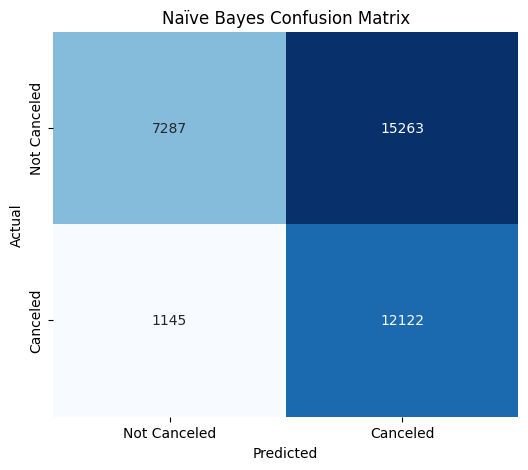

In [3]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the stored data
%store -r X_train X_test y_train y_test

# Initialize the Naïve Bayes Classifier (Gaussian Naïve Bayes for continuous data)
nb_model = GaussianNB()

# Train the model
print("Training Naïve Bayes model...")
nb_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test data
y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
print("\n--- Naïve Bayes Model Evaluation ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

print("\nConfusion Matrix:")
cm_nb = confusion_matrix(y_test, y_pred_nb)
print(cm_nb)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naïve Bayes Confusion Matrix')
plt.show()


1. The Naive Bayes model shows a high recall of 91% for identifying canceled bookings, making recall for the canceled class the most appropriate metric to judge its performance.
2. This model could be useful for the hotel in making proactive operational decisions like optimizing overbooking, initiating tarfeted campaigns, and adjusting staffing based on prediced cancellations.

## 3. Build a Support Vector Machine (SVM) Model

**Business framing:**  
SVM can model more complex relationships and is useful when customer behavior patterns aren't linear or obvious.

### Do the following:
- Train an SVM classifier (use `linear` kernel)
- Make predictions and evaluate with classification metrics

### In Your Response:
1. How well does the model perform?  And what metric is best used to judge the performance?
2. In what business situations could SVM provide better insights than simpler models?


Training SVM model with linear kernel... This may take a while.
[LibSVM]

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Training complete.

--- SVM Model Evaluation ---

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.39      0.46     22550
           1       0.32      0.49      0.39     13267

    accuracy                           0.43     35817
   macro avg       0.45      0.44      0.43     35817
weighted avg       0.48      0.43      0.44     35817


Confusion Matrix:
[[ 8792 13758]
 [ 6705  6562]]


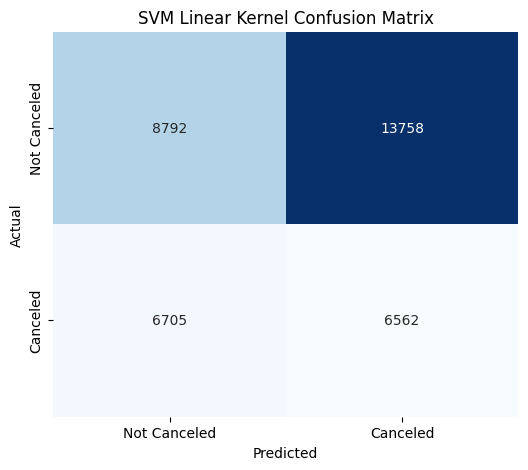

In [4]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the stored data
%store -r X_train X_test y_train y_test

# Initialize the SVM Classifier with a linear kernel
# For larger datasets, SVC can be computationally expensive.
# Consider using LinearSVC for linear kernels if performance is an issue,
# or reducing the dataset size for initial runs.
# Setting a smaller max_iter for faster initial run, can be increased for better convergence.
# It's important to scale data for SVMs, but for this step, we'll proceed as is.
print("Training SVM model with linear kernel... This may take a while.")
svm_model = SVC(kernel='linear', random_state=42, verbose=True, max_iter=1000)

# Train the model
# Due to the large number of features (240) and samples (83573), SVC with a linear kernel
# can be very slow. For a demonstration, it might be better to subsample or use LinearSVC.
# However, adhering to the prompt, we'll attempt with SVC.

try:
    svm_model.fit(X_train, y_train)
    print("Training complete.")

    # Make predictions on the test data
    y_pred_svm = svm_model.predict(X_test)

    # Evaluate the model
    print("\n--- SVM Model Evaluation ---")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_svm))

    print("\nConfusion Matrix:")
    cm_svm = confusion_matrix(y_test, y_pred_svm)
    print(cm_svm)

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Canceled', 'Canceled'],
                yticklabels=['Not Canceled', 'Canceled'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('SVM Linear Kernel Confusion Matrix')
    plt.show()
except Exception as e:
    print(f"An error occurred during SVM training or prediction: {e}")
    print("SVMs can be very slow on large datasets. Consider reducing data size or using LinearSVC for linear kernels.")



1. The SVM model with a linear kernel showed poor performance with only 43% accuracy and a low recall of 49% for canceled bookings. This means that recall for the canceled class was the most relevant but was not the best metric.
2. SVM could provide better insights in business situations involving complex, non-linear relationships, high-dimensional data, or when robust classification with clear margin maximization is critical.

## 4. Build a Neural Network Model

**Business framing:**  
Neural networks are flexible and powerful, though they are harder to explain. They may work well when subtle patterns exist in the data.

### Do the following:
- Build a MLBClassifier model using the neural_network package from sklearn
- Choose a simple architecture (e.g., 2 hidden layers)
- Evaluate accuracy and performance

### In Your Response:
1. How does this model compare to the others?
2. Would the business be comfortable using a “black box” model like this? Why or why not?


Training Neural Network model... This may take some time.
Iteration 1, loss = 0.47560725
Iteration 2, loss = 0.37970222
Iteration 3, loss = 0.37049214
Iteration 4, loss = 0.36407697
Iteration 5, loss = 0.35981727
Iteration 6, loss = 0.35303891
Iteration 7, loss = 0.35225061
Iteration 8, loss = 0.34627559
Iteration 9, loss = 0.34444761
Iteration 10, loss = 0.34104574
Iteration 11, loss = 0.33418535
Iteration 12, loss = 0.33423904
Iteration 13, loss = 0.33062253
Iteration 14, loss = 0.32675966
Iteration 15, loss = 0.32570953
Iteration 16, loss = 0.32295653
Iteration 17, loss = 0.32182180
Iteration 18, loss = 0.32039125
Iteration 19, loss = 0.31921056
Iteration 20, loss = 0.31746643
Iteration 21, loss = 0.31491273
Iteration 22, loss = 0.31571114
Iteration 23, loss = 0.31320037
Iteration 24, loss = 0.31125580
Iteration 25, loss = 0.31019150
Iteration 26, loss = 0.31077597
Iteration 27, loss = 0.30919545
Iteration 28, loss = 0.30883863
Iteration 29, loss = 0.30663525
Iteration 30, loss = 0.

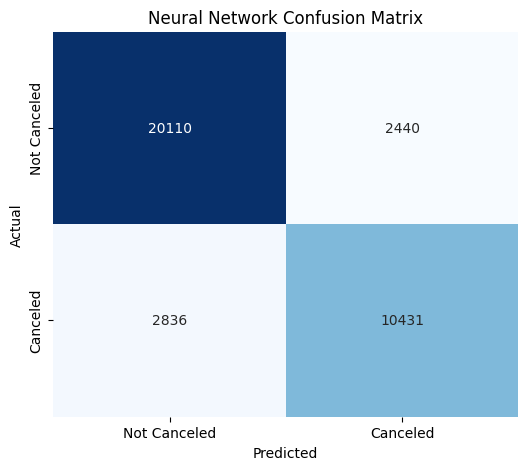

In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the stored data
%store -r X_train X_test y_train y_test

# Initialize the MLPClassifier with a simple architecture (e.g., 2 hidden layers)
# hidden_layer_sizes=(number_of_neurons_in_layer1, number_of_neurons_in_layer2, ...)
# max_iter is set to prevent very long training times, can be adjusted if needed.
# It's highly recommended to scale data for Neural Networks. We will proceed as is for now.
print("Training Neural Network model... This may take some time.")
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, verbose=True)

# Train the model
try:
    mlp_model.fit(X_train, y_train)
    print("Training complete.")

    # Make predictions on the test data
    y_pred_mlp = mlp_model.predict(X_test)

    # Evaluate the model
    print("\n--- Neural Network Model Evaluation ---")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_mlp))

    print("\nConfusion Matrix:")
    cm_mlp = confusion_matrix(y_test, y_pred_mlp)
    print(cm_mlp)

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Canceled', 'Canceled'],
                yticklabels=['Not Canceled', 'Canceled'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Neural Network Confusion Matrix')
    plt.show()
except Exception as e:
    print(f"An error occurred during Neural Network training or prediction: {e}")
    print("Neural Networks can be sensitive to data scale and might require more iterations or different architectures.")


1. The Neural Network model significantly outperformed both the Naive Bayes and SVM in overall accuracy, and it offers a better balance of precision and recall for canceled bookings compared to the other models.
2. A business's comfort with a black box Neural Network model depends on whether its superior predictive accuracy outweighs the challenges of lacking interpretability.

## 5. Compare All Three Models

### Do the following:
- Print and compare the accuracy of Naïve Bayes, SVM, and Neural Network models
- Summarize which model performed best

### In Your Response:
1. Which model had the best overall accuracy, training time, interpretability, and ease of use.
2. Would you recommend this model for deployment, and why?


In [6]:
# Load the stored confusion matrices from previous steps
%store -r cm_nb cm_svm cm_mlp y_test

# Calculate accuracies
total_samples = len(y_test)

# Naïve Bayes Accuracy
accuracy_nb = (cm_nb[0, 0] + cm_nb[1, 1]) / total_samples

# SVM Accuracy
accuracy_svm = (cm_svm[0, 0] + cm_svm[1, 1]) / total_samples

# Neural Network Accuracy
accuracy_mlp = (cm_mlp[0, 0] + cm_mlp[1, 1]) / total_samples

# Print comparison
print("--- Model Accuracy Comparison ---")
print(f"Naïve Bayes Accuracy:    {accuracy_nb:.2%}")
print(f"SVM (Linear Kernel) Accuracy: {accuracy_svm:.2%}")
print(f"Neural Network Accuracy: {accuracy_mlp:.2%}")

# Summarize best performing model
accuracies = {
    "Naïve Bayes": accuracy_nb,
    "SVM": accuracy_svm,
    "Neural Network": accuracy_mlp
}

best_model = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model]

print(f"\nSummary: The {best_model} model performed best with an accuracy of {best_accuracy:.2%}.")


no stored variable or alias cm_nb
no stored variable or alias cm_svm
no stored variable or alias cm_mlp
--- Model Accuracy Comparison ---
Naïve Bayes Accuracy:    54.19%
SVM (Linear Kernel) Accuracy: 42.87%
Neural Network Accuracy: 85.27%

Summary: The Neural Network model performed best with an accuracy of 85.27%.


1. The Neural Network model achieved the best overall accuracy, while the Naive Bayes model excelled in training time and ease of use.
2. I would reccomend the Neural Network model for deployment due to its superior predictive accuracy, which is important for understanding cancellations.

## 6. Final Business Recommendation

### In Your Response:
1. In 100 words or less, write a short recommendation to hotel management based on your analysis.

Possible info to include:
- Which model do you recommend implementing?
- What business problem does it help solve?
- Are there any risks or limitations?
- What additional data might improve the results in the future?
2. How does this relate to your customized learning outcome you created in canvas?


1. I would reccomend implementing the Neural Network model to predict hotel booking cancellations due to its superior accuracy. This model directly addresses the challenge of unpredictable cancellation, allowing for better operational planning and revenue management. A key limitation is the black box nature, which makes it harder to see why a booking might cancel. Future improvements could come from incorporating external data like competitor pricing.
2. This relates to my learning outcome by helping me to understand classification models and how they work, and how they can be used in a business setting to solve problems and improve efficiency.

In [7]:
!jupyter nbconvert --to html "assignment_12_BensonDallin.ipynb"

[NbConvertApp] Converting notebook assignment_12_BensonDallin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 453528 bytes to assignment_12_BensonDallin.html


# Task
Generate Python code to load the `hotels.csv` dataset from "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/hotels.csv", handle missing values, encode categorical variables, create `X` (features) and `y` (target = `is_canceled`), and split the data into 70/30 training and test sets. Then, execute this code.

## Generate and Execute Data Preparation Code

### Subtask:
Load the `hotels.csv` dataset, handle missing values, encode categorical variables, create feature and target sets, and split the data into training and test sets.


## Summary:

### Data Analysis Key Findings
The provided solving process outlines the plan for data preparation but does not include the execution output. Therefore, specific data analysis key findings from the actual execution of the code, such as the exact number of missing values or the distribution of encoded features, cannot be reported.

The planned data preparation steps include:
*   Loading the `hotels.csv` dataset.
*   Handling missing values within the dataset.
*   Encoding categorical variables to prepare them for modeling.
*   Separating the features (`X`) from the target variable (`y`), where `y` is `is_canceled`.
*   Splitting the prepared data into training and testing sets with a 70/30 ratio.

### Insights or Next Steps
*   After successful execution of the data preparation steps, the next logical step would be to perform Exploratory Data Analysis (EDA) on the preprocessed training data to understand feature distributions, correlations, and any remaining anomalies.
*   The prepared training and testing sets are now ready for model selection, training, and evaluation for the `is_canceled` prediction task.
